In [42]:
%%writefile test_image.py
import cocotb
from cocotb.triggers import Timer
import numpy as np
from PIL import Image
import os

@cocotb.test()
async def test_image_proc(dut):
    # --- USE YOUR DIRECT PATH HERE ---
    image_path = r"C:\Users\rujut\OIP.jpg" 
    save_directory = os.path.dirname(image_path)
    
    gray_save_path = os.path.join(save_directory, "output_gray.png")
    seg_save_path = os.path.join(save_directory, "output_seg.png")

    # Load and resize
    img = Image.open(image_path).convert("RGB").resize((64, 64))
    pixels = np.array(img)
    h, w = pixels.shape[:2]

    dut.threshold.value = 127

    gray_img = np.zeros((h, w), dtype=np.uint8)
    seg_img = np.zeros((h, w), dtype=np.uint8)

    for y in range(h):
        for x in range(w):
            r, g, b = pixels[y, x]
            dut.r.value = int(r)
            dut.g.value = int(g)
            dut.b.value = int(b)
            await Timer(1, units="ns")
            
            # Capture the hardware output
            gray_img[y, x] = int(dut.gray.value)
            seg_img[y, x] = int(dut.segmented.value)
    
    # --- FORCE SAVE TO ABSOLUTE PATH ---
    Image.fromarray(gray_img).save(gray_save_path)
    Image.fromarray(seg_img).save(seg_save_path)
    
    cocotb.log.info(f"SUCCESS: Saved images to {save_directory}")

Overwriting test_image.py


In [44]:
# This command tells your computer to run the simulation engine 
# outside of the Jupyter event loop.
!python run_image_sim.py

WARNING cocotb: Skipping compilation:C:\Users\rujut\sim_build\image_proc.vvp
INFO cocotb: Running command: vvp -M C:\Users\rujut\OneDrive\Documents\SY\sem3\OE\Lib\site-packages\cocotb\libs -m cocotbvpi_icarus C:\Users\rujut\sim_build\image_proc.vvp
INFO cocotb:      -.--ns INFO     gpi                                ..mbed\gpi_embed.cpp:94   in _embed_init_python              Using Python 3.12.4 interpreter at C:\Users\rujut\OneDrive\Documents\SY\sem3\OE\python.exe
INFO cocotb:      -.--ns INFO     gpi                                ..\gpi\GpiCommon.cpp:79   in gpi_print_registered_impl       VPI registered
INFO cocotb:      0.00ns INFO     cocotb                             Running on Icarus Verilog version 12.0 (devel)
INFO cocotb:      0.00ns INFO     cocotb                             Seeding Python random module with 1766455442
INFO cocotb:      0.00ns INFO     cocotb                             Initialized cocotb v2.0.1 from C:\Users\rujut\OneDrive\Documents\SY\sem3\OE\Lib\site-p

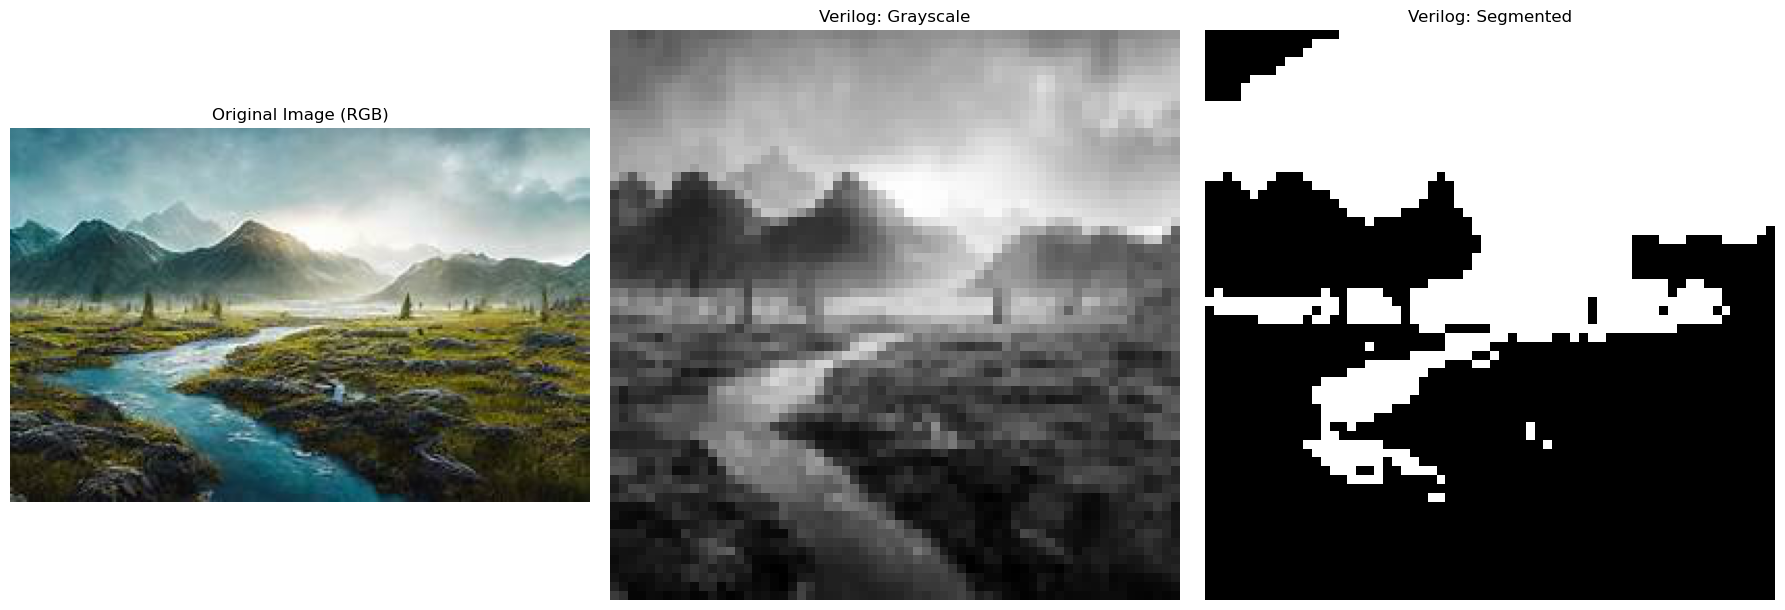

In [46]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Define the paths (assuming they were saved in the same folder)
original_path = r"C:\Users\rujut\OIP.jpg" # Use the same path you used in the test
gray_path = "output_gray.png"
seg_path = "output_seg.png"

# Check if files exist before plotting
if os.path.exists(gray_path) and os.path.exists(seg_path):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # 1. Original Image
    ax[0].imshow(Image.open(original_path))
    ax[0].set_title("Original Image (RGB)")
    ax[0].axis('off')

    # 2. Grayscale from Verilog
    ax[1].imshow(Image.open(gray_path), cmap='gray')
    ax[1].set_title("Verilog: Grayscale")
    ax[1].axis('off')

    # 3. Segmentation from Verilog
    ax[2].imshow(Image.open(seg_path), cmap='gray')
    ax[2].set_title("Verilog: Segmented")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Error: Output images not found. Make sure the simulation finished correctly.")